<a href="https://colab.research.google.com/github/Ab-tldr/Movie-review-Sentiment-Analysis/blob/main/hybrid_arima_lstm_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/air_quality/"

In [ ]:
df = pd.read_csv(DATA_PATH + "dataset/city_day.csv", low_memory=False)


In [ ]:
stations = pd.read_csv(DATA_PATH +'dataset/stations.csv')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(['City', 'Date'], inplace=True)

###AQI CALCULATION

In [ ]:
def get_subindex(pollutant, value):
    if pd.isna(value) or value <= 0: return 0
    bp = {
        'PM2.5': [(0,30,0,50), (30,60,50,100), (60,90,100,200), (90,120,200,300), (120,250,300,400), (250,1000,400,500)],
        'PM10': [(0,50,0,50), (50,100,50,100), (100,250,100,200), (250,350,200,300), (350,430,300,400), (430,1000,400,500)],
        'NO2': [(0,40,0,50), (40,80,50,100), (80,180,100,200), (180,280,200,300), (280,400,300,400), (400,1000,400,500)],
        'SO2': [(0,40,0,50), (40,80,50,100), (80,380,100,200), (380,800,200,300), (800,1600,300,400), (1600,2000,400,500)],
        'CO': [(0,1,0,50), (1,2,50,100), (2,10,100,200), (10,17,200,300), (17,34,300,400), (34,100,400,500)],
        'NH3': [(0,200,0,50), (200,400,50,100), (400,800,100,200), (800,1200,200,300), (1200,1800,300,400), (1800,3000,400,500)]
    }
    if pollutant not in bp: return 0
    for (cl, ch, il, ih) in bp[pollutant]:
        if cl <= value <= ch:
            return il + (value - cl) * (ih - il) / (ch - cl)
    return 500



In [ ]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'NH3']


In [ ]:
for p in pollutants:
    df[f'{p}_si'] = df[p].apply(lambda x: get_subindex(p, x))

df['New_AQI'] = df[[f'{p}_si' for p in pollutants]].max(axis=1)

In [ ]:
city_data = df[df['City'] == 'Delhi'].copy()
city_data = city_data.sort_values('Date').set_index('Date')

In [ ]:
aqi_series = city_data[['New_AQI']].resample('D').mean()


In [ ]:
aqi_series = aqi_series.interpolate(method='time')
aqi_series = aqi_series.rolling(3).mean().dropna()

series = aqi_series['New_AQI']

In [ ]:
values = series.values

split = int(len(values) * 0.8)

train, test = values[:split], values[split:]

In [ ]:
history = list(train)
arima_preds = []

print("Running ARIMA...")

for t in range(len(test)):

    model = ARIMA(history, order=(2,0,2))
    model_fit = model.fit()

    forecast = model_fit.forecast()[0]
    arima_preds.append(forecast)

    history.append(test[t])

Running ARIMA...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

In [ ]:
import pickle


In [ ]:
final_arima = ARIMA(values, order=(2,0,2)).fit()
pickle.dump(final_arima, open("arima_model.pkl", "wb"))

In [ ]:
rmse_arima = np.sqrt(mean_squared_error(test, arima_preds))
mae_arima  = mean_absolute_error(test, arima_preds)

print(f"ARIMA RMSE: {rmse_arima:.2f}")
print(f"ARIMA MAE : {mae_arima:.2f}")

ARIMA RMSE: 16.77
ARIMA MAE : 12.17


In [ ]:
residuals = test - arima_preds

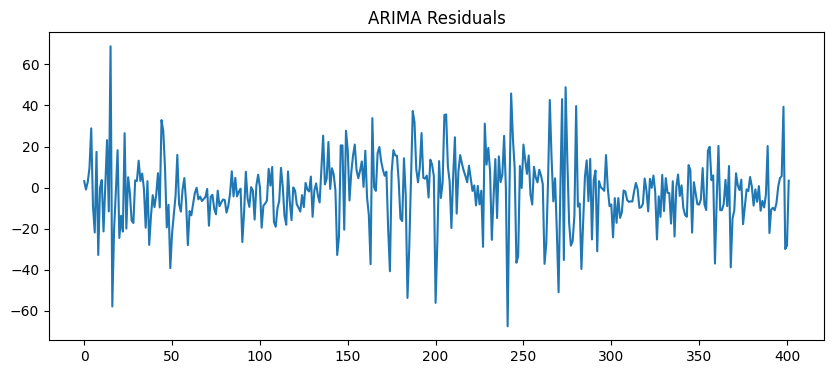

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()

In [ ]:
scaler = MinMaxScaler()

residuals = residuals.reshape(-1,1)

scaled_residuals = scaler.fit_transform(residuals)

In [ ]:
def create_windows(data, lookback=30):

    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)


LOOKBACK = 30

X, y = create_windows(scaled_residuals, LOOKBACK)

In [ ]:
split_lstm = int(len(X) * 0.8)

X_train, X_test = X[:split_lstm], X[split_lstm:]
y_train, y_test = y[:split_lstm], y[split_lstm:]

In [ ]:
model = Sequential([

    LSTM(64, return_sequences=True,
         input_shape=(LOOKBACK,1)),

    Dropout(0.3),

    LSTM(32),

    Dropout(0.3),

    Dense(1)
])

model.compile(optimizer='adam', loss='mae')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=7,
#     restore_best_weights=True
# )

history2 = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    #callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.2983 - val_loss: 0.1356
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1357 - val_loss: 0.0884
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1155 - val_loss: 0.0768
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1148 - val_loss: 0.0735
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1098 - val_loss: 0.0723
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1169 - val_loss: 0.0722
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1053 - val_loss: 0.0726
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1083 - val_loss: 0.0737
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1026 - val_loss: 0.0725
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1067 - val_loss: 0.0723
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0987 - val_loss: 0.0730
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1

In [ ]:
lstm_residual_preds = model.predict(X_test)

lstm_residual_preds = scaler.inverse_transform(lstm_residual_preds)
y_test_inv = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step


In [ ]:
aligned_arima = arima_preds[-len(lstm_residual_preds):]
aligned_actual = test[-len(lstm_residual_preds):]

In [ ]:
hybrid_preds = aligned_arima + lstm_residual_preds.flatten()

In [ ]:
rmse_hybrid = np.sqrt(
    mean_squared_error(aligned_actual, hybrid_preds)
)

mae_hybrid = mean_absolute_error(
    aligned_actual, hybrid_preds
)

print(f"\nHybrid RMSE: {rmse_hybrid:.2f}")
print(f"Hybrid MAE : {mae_hybrid:.2f}")


Hybrid RMSE: 12.94
Hybrid MAE : 9.79


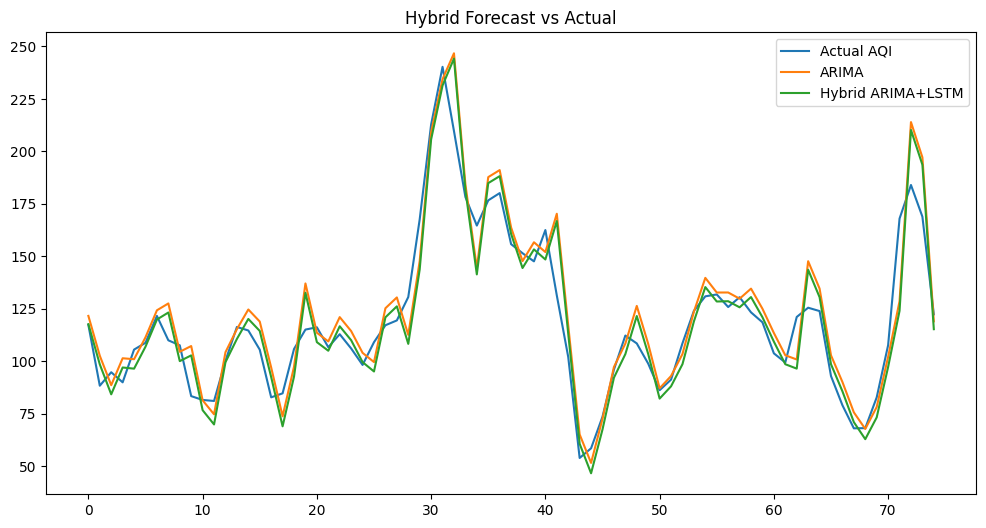

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(aligned_actual, label='Actual AQI')
plt.plot(aligned_arima, label='ARIMA')
plt.plot(hybrid_preds, label='Hybrid ARIMA+LSTM')

plt.title("Hybrid Forecast vs Actual")
plt.legend()
plt.show()

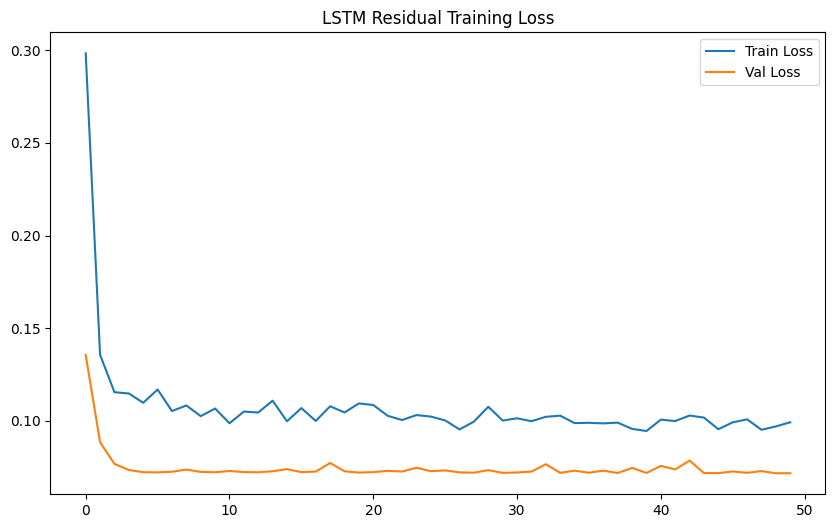

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title("LSTM Residual Training Loss")
plt.legend()
plt.show()

In [ ]:
model.save("lstm_model.h5")


In [ ]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Models saved successfully!")

Models saved successfully!


In [ ]:
from google.colab import files

files.download("arima_model.pkl")
files.download("lstm_model.h5")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pickle.dump(final_arima, open(DATA_PATH + "arima_model.pkl", "wb"))
model.save(DATA_PATH + "lstm_model.h5")
pickle.dump(scaler, open(DATA_PATH + "scaler.pkl", "wb"))

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def get_aqi_bucket(x):
    if x <= 50: return "Good"
    elif x <= 100: return "Satisfactory"
    elif x <= 200: return "Moderate"
    elif x <= 300: return "Poor"
    elif x <= 400: return "Very Poor"
    else: return "Severe"

actual_buckets = [get_aqi_bucket(val) for val in aligned_actual]
pred_buckets   = [get_aqi_bucket(val) for val in hybrid_preds]

labels = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]


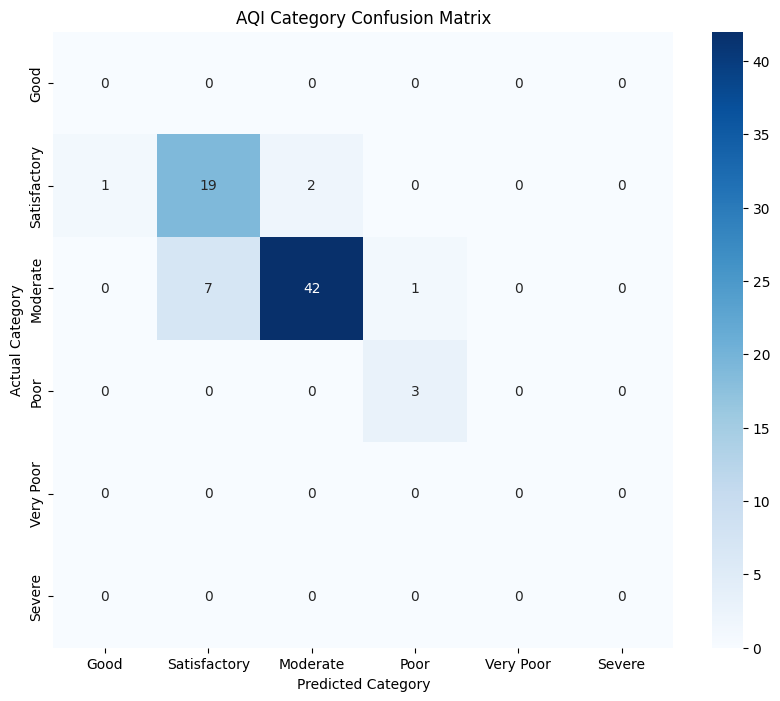

Classification Accuracy: 0.8533

Classification Report:

              precision    recall  f1-score   support

        Good       0.00      0.00      0.00         0
Satisfactory       0.73      0.86      0.79        22
    Moderate       0.95      0.84      0.89        50
        Poor       0.75      1.00      0.86         3
   Very Poor       0.00      0.00      0.00         0
      Severe       0.00      0.00      0.00         0

    accuracy                           0.85        75
   macro avg       0.41      0.45      0.42        75
weighted avg       0.88      0.85      0.86        75



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [ ]:

cm = confusion_matrix(actual_buckets, pred_buckets, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues')

plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('AQI Category Confusion Matrix')
plt.show()

acc = accuracy_score(actual_buckets, pred_buckets)
print(f"Classification Accuracy: {acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(actual_buckets, pred_buckets, labels=labels))